In [2]:

import os
os.getcwd()

'C:\\Users\\sai vaishnavi reddy\\Untitled Folder 2'

In [3]:
import pandas as pd

df=pd.read_csv("bank-full.csv",sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [14]:
df.shape
df.columns
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [15]:
df.duplicated().sum()
df.dtypes
df.describe()
df['y'].value_counts()


y
no     39922
yes     5289
Name: count, dtype: int64

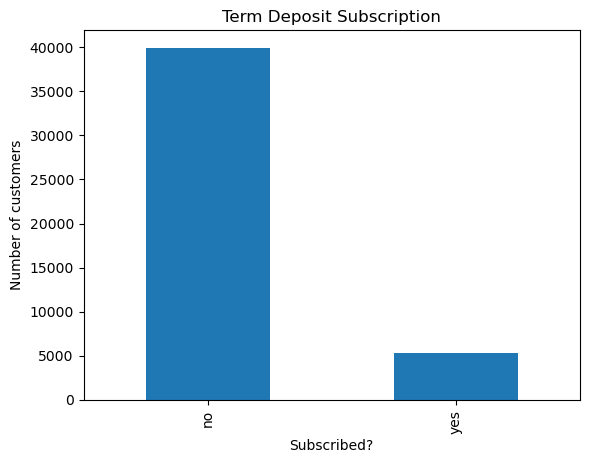

In [17]:
import matplotlib.pyplot as plt
df['y'].value_counts().plot(kind='bar')
plt.xlabel("Subscribed?")
plt.ylabel("Number of customers")
plt.title("Term Deposit Subscription")
plt.show()

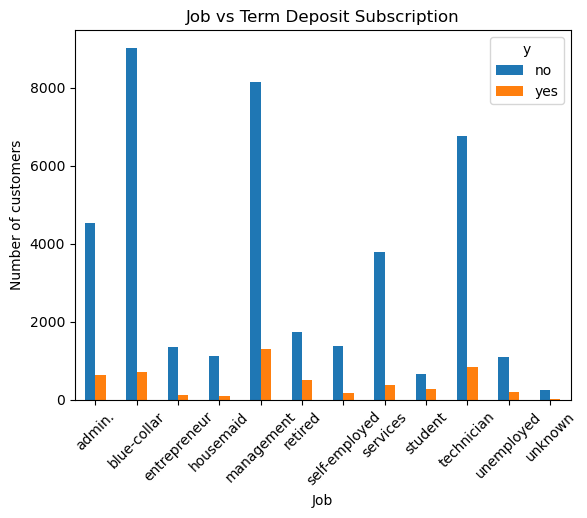

y,no,yes
job,,
admin.,87.797331,12.202669
blue-collar,92.725031,7.274969
entrepreneur,91.728312,8.271688
housemaid,91.209677,8.790323
management,86.244449,13.755551
retired,77.208481,22.791519
self-employed,88.157061,11.842939
services,91.116996,8.883004
student,71.321962,28.678038


In [22]:
pd.crosstab(df['job'], df['y'])
pd.crosstab(df['job'], df['y']).plot(kind='bar')
plt.xlabel("Job")
plt.ylabel("Number of customers")
plt.title("Job vs Term Deposit Subscription")
plt.xticks(rotation=45)
plt.show()
job_rate = pd.crosstab(df['job'], df['y'], normalize='index') * 100
job_rate

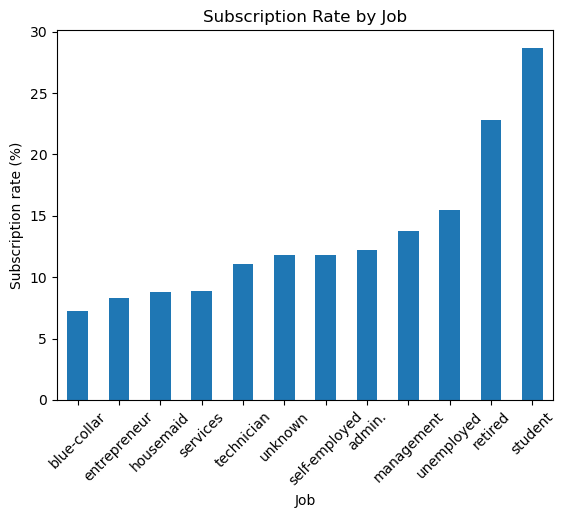

In [23]:
job_rate['yes'].sort_values().plot(kind='bar')
plt.xlabel("Job")
plt.ylabel("Subscription rate (%)")
plt.title("Subscription Rate by Job")
plt.xticks(rotation=45)
plt.show()

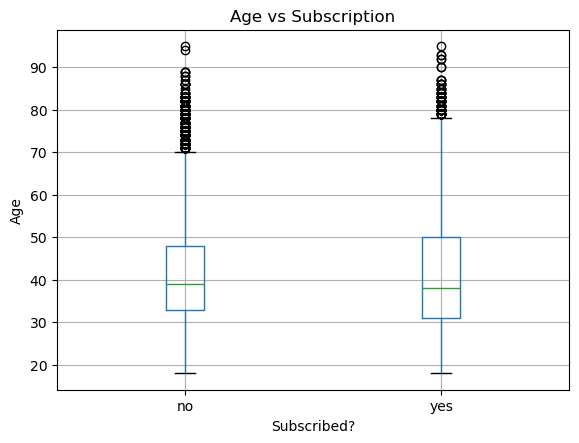

In [24]:
df.boxplot(column='age', by='y')
plt.xlabel("Subscribed?")
plt.ylabel("Age")
plt.title("Age vs Subscription")
plt.suptitle("")
plt.show()



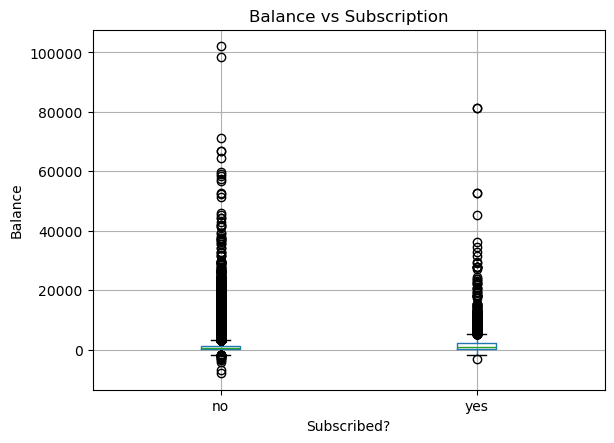

In [25]:
df.boxplot(column='balance', by='y')
plt.xlabel("Subscribed?")
plt.ylabel("Balance")
plt.title("Balance vs Subscription")
plt.suptitle("")
plt.show()

In [26]:
df['education'].value_counts()

pd.crosstab(df['education'], df['y'])

education_rate = pd.crosstab(
    df['education'],
    df['y'],
    normalize='index'
) * 100

education_rate

y,no,yes
education,,
primary,91.373522,8.626478
secondary,89.440565,10.559435
tertiary,84.993610,15.006390
unknown,86.429725,13.570275


In [33]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})
df['y'].value_counts()


In [35]:
X = df.drop('y', axis=1)

X = pd.get_dummies(X, drop_first=True)

X.head()


In [39]:
y = df['y']

In [45]:
df = pd.read_csv("bank-full.csv", sep=";")

df['y'] = df['y'].map({'yes': 1, 'no': 0})

X = df.drop('y', axis=1)
X = pd.get_dummies(X, drop_first=True)

y = df['y']
y.isnull().sum()

np.int64(0)

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred[:20])
print(y_test[:20].values)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

(36168, 42)
(9043, 42)
(36168,)
(9043,)
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0]
0.8947252018135574


C:\Users\sai vaishnavi reddy\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [52]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[7810  175]
 [ 777  281]]


In [ ]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Pandas → work with tables/data
# Matplotlib → create graphs


# ============================================================
# 2. LOAD THE DATASET
# ============================================================

df = pd.read_csv("bank-full.csv", sep=";")

# sep=";" because this CSV uses ; between columns


# ============================================================
# 3. UNDERSTAND THE DATA
# ============================================================

print("Shape:", df.shape)
# Shape → (rows, columns)

print("\nColumns:")
print(df.columns)
# Shows all column names

print("\nData types:")
print(df.dtypes)
# Shows whether each column is numerical or categorical

print("\nMissing values:")
print(df.isnull().sum())
# Checks missing/null values

print("\nDuplicate rows:")
print(df.duplicated().sum())
# Counts completely duplicate rows

print("\nNumerical summary:")
print(df.describe())
# Gives count, mean, min, max, quartiles, etc.


# ============================================================
# 4. UNDERSTAND THE TARGET
# ============================================================

print("\nTarget distribution:")
print(df['y'].value_counts())

# y is our TARGET:
# yes → customer subscribed
# no  → customer did not subscribe


# ============================================================
# 5. BASIC EDA / VISUALIZATION
# ============================================================

# Target distribution
df['y'].value_counts().plot(kind='bar')
plt.xlabel("Subscribed?")
plt.ylabel("Number of customers")
plt.title("Term Deposit Subscription")
plt.show()


# Categorical feature vs target
job_rate = pd.crosstab(
    df['job'],
    df['y'],
    normalize='index'
) * 100

print(job_rate)

job_rate['yes'].sort_values().plot(kind='bar')
plt.xlabel("Job")
plt.ylabel("Subscription rate (%)")
plt.title("Subscription Rate by Job")
plt.xticks(rotation=45)
plt.show()


# Numerical feature vs target
df.boxplot(column='age', by='y')
plt.xlabel("Subscribed?")
plt.ylabel("Age")
plt.title("Age vs Subscription")
plt.suptitle("")
plt.show()


# ============================================================
# 6. CONVERT TARGET: YES/NO → 1/0
# ============================================================

df['y'] = df['y'].map({
    'yes': 1,
    'no': 0
})

# Machine-learning models work with numerical target values.
# 1 → subscribed
# 0 → not subscribed


# ============================================================
# 7. CREATE X AND y
# ============================================================

X = df.drop('y', axis=1)

# X = INPUT FEATURES
# Everything except the target y

y = df['y']

# y = TARGET
# The answer that the model needs to predict


# ============================================================
# 8. CONVERT CATEGORICAL FEATURES INTO NUMBERS
# ============================================================

X = pd.get_dummies(X, drop_first=True)

# Converts text categories into True/False (0/1)
# Example:
# job_student → True/False
# job_technician → True/False
#
# drop_first=True removes one unnecessary category
#
# After encoding, our X has 42 columns.


# ============================================================
# 9. CHECK X AND y
# ============================================================

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values in y:", y.isnull().sum())

# X and y must have the same number of rows.


# ============================================================
# 10. TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 80% → training data
# 20% → testing data
#
# X_train + y_train → model learns
# X_test             → model makes predictions
# y_test             → actual answers used for evaluation
#
# stratify=y keeps the 0/1 proportion similar
# random_state=42 gives the same split each time


# ============================================================
# 11. BUILD THE FIRST MODEL
# ============================================================

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)

# Logistic Regression is used because this is
# a BINARY CLASSIFICATION problem:
#
# 0 → No
# 1 → Yes
#
# This is our first BASELINE model.


# ============================================================
# 12. TRAIN THE MODEL
# ============================================================

model.fit(X_train, y_train)

# fit() → model learns patterns from training data


# ============================================================
# 13. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

# y_pred → model's predictions for unseen test data


print("Predictions:")
print(y_pred[:20])

print("\nActual:")
print(y_test[:20].values)


# ============================================================
# 14. ACCURACY
# ============================================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Accuracy = correctly predicted customers / total customers


# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Because y has 2 classes (0 and 1),
# the confusion matrix is 2 × 2:
#
#              Predicted
#              0       1
# Actual  0    TN      FP
#         1    FN      TP
#
# TN = Actual 0, predicted 0
# FP = Actual 0, predicted 1
# FN = Actual 1, predicted 0
# TP = Actual 1, predicted 1